# Gaussian Process Regression

This lab explores Gaussian Process Regression (GPR) using the `GPy` library. We will cover topics including visualizing the GP prior, fitting a GP model, kernel selection, hyperparameter tuning, sparse GPs, and evaluation.

To get us started, let's install the necessary libraries, imports and generate some synthetic data. 



In [58]:
# Install necessary libraries (uncomment if needed)
# !pip install GPy
import GPy
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Generate synthetic data
np.random.seed(42)
X_train = np.linspace(-5, 5, 20)[:, None]
Y_train = np.sin(X_train) + 0.5 * np.random.randn(20, 1)  # Noisy sine wave data

# Define test points for visualization
X_test = np.linspace(-6, 6, 100)[:, None]


## Background 

Gaussian Process Regression (GPR) provides a non-parametric Bayesian framework for regression. Let's review the formulation of GPR before we run some code:

### 1. Gaussian Process Definition

A Gaussian Process is defined as a collection of random variables, any finite number of which have a joint Gaussian distribution. It is specified by:
- A **mean function** $m(x)$
- A **covariance function** (or kernel) $k(x, x')$

$$
f(x) \sim \mathcal{GP}(m(x), k(x, x'))
$$

Where:
$$
m(x) = \mathbb{E}[f(x)], \quad k(x, x') = \mathbb{E}[(f(x) - m(x))(f(x') - m(x'))]
$$

Typically, the mean function is assumed to be zero ($m(x) = 0$).

### 2. Prior Distribution

Given a set of $N$ input points $X = \{x_1, x_2, \dots, x_N\}$, the corresponding function values $f(X)$ follow a multivariate Gaussian distribution:

$$
f(X) \sim \mathcal{N}(0, K(X, X))
$$

Where $K(X, X)$ is the covariance matrix computed using the kernel $k(x, x')$.

We start by generating noisy data from a sine function. Then, we visualize sample functions from a Gaussian Process prior.



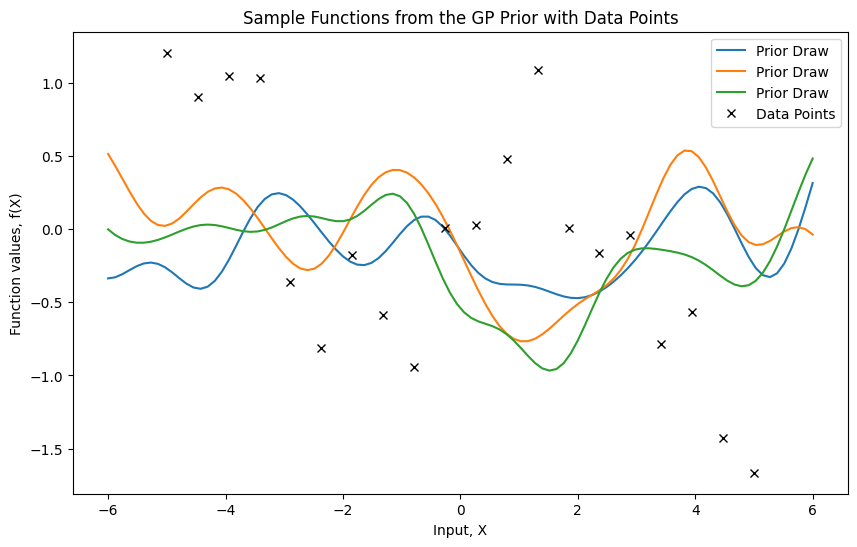

In [59]:

# Define an RBF kernel
kernel = GPy.kern.RBF(input_dim=1, variance=1.0, lengthscale=1.0)

# Visualize the GP prior
model_prior = GPy.models.GPRegression(X_test, np.zeros(X_test.shape), kernel)
plt.figure(figsize=(10, 6))

# Plot prior samples
for _ in range(3):
    sample = model_prior.posterior_samples_f(X_test, size=1).squeeze()
    plt.plot(X_test, sample, lw=1.5, label="Prior Draw")

# Plot data points
plt.plot(X_train, Y_train, 'kx', label="Data Points")  # 'kx' for black crosses

plt.title("Sample Functions from the GP Prior with Data Points")
plt.xlabel("Input, X")
plt.ylabel("Function values, f(X)")
plt.legend()
plt.show()

### 3. Likelihood with Noise

For noisy observations $y$, the outputs are modeled as:

$$
y = f(X) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_n^2 I)
$$

The likelihood becomes:

$$
y \sim \mathcal{N}(0, K(X, X) + \sigma_n^2 I)
$$

### 4. Posterior Distribution

Given the observed data $(X, y)$, the goal is to predict the function value $f(x_*)$ at a new input $x_*$. The joint distribution of $y$ and $f(x_*)$ is:

$$
\begin{bmatrix}
y \\
f(x_*)
\end{bmatrix}
\sim \mathcal{N} \left(
0,
\begin{bmatrix}
K(X, X) + \sigma_n^2 I & K(X, x_*) \\
K(x_*, X) & K(x_*, x_*)
\end{bmatrix}
\right)
$$

From the properties of multivariate Gaussians, the posterior predictive distribution $f(x_*) | X, y, x_*$ is:

$$
f(x_*) | X, y, x_* \sim \mathcal{N}(\mu(x_*), \sigma^2(x_*))
$$

Where:
- **Mean**:
  $$
  \mu(x_*) = K(x_*, X) [K(X, X) + \sigma_n^2 I]^{-1} y
  $$
- **Variance**:
  $$
  \sigma^2(x_*) = K(x_*, x_*) - K(x_*, X) [K(X, X) + \sigma_n^2 I]^{-1} K(X, x_*)
  $$

We now fit a GP model to the generated data using an RBF kernel.

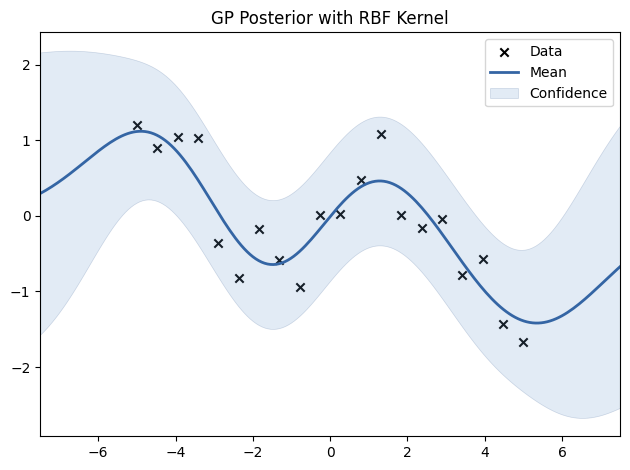

In [60]:
# Fit GP model with RBF kernel
model = GPy.models.GPRegression(X_train, Y_train, kernel)
model.optimize(messages=True)

# Plot posterior
model.plot(title="GP Posterior with RBF Kernel")
plt.show()

### 5. Kernel Function

The kernel $k(x, x')$ defines the covariance between function values and encapsulates assumptions about the function. Common kernels include:
- **Radial Basis Function (RBF)**:
  $$
  k(x, x') = \sigma_f^2 \exp\left(-\frac{|x - x'|^2}{2 \ell^2}\right)
  $$
  Where $\ell$ is the length scale and $\sigma_f^2$ is the signal variance.

- **Matern Kernel**:
  $$
  k(x, x') = \sigma_f^2 \frac{2^{1-\nu}}{\Gamma(\nu)} \left( \frac{\sqrt{2\nu} |x - x'|}{\ell} \right)^\nu K_\nu \left( \frac{\sqrt{2\nu} |x - x'|}{\ell} \right)
  $$
  Where $\nu$ controls smoothness and $K_\nu$ is the modified Bessel function.

We experiment with different kernels, including RBF, Matern, Periodic, and Linear, to see how they affect the fit.



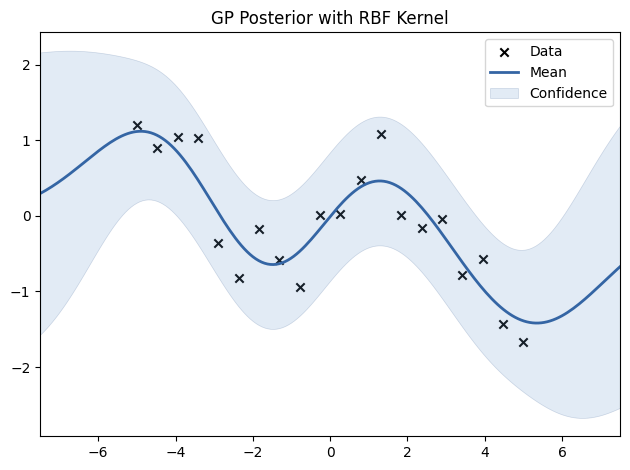

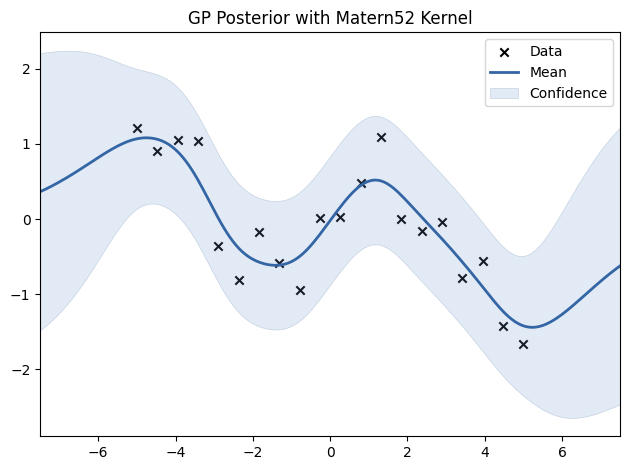

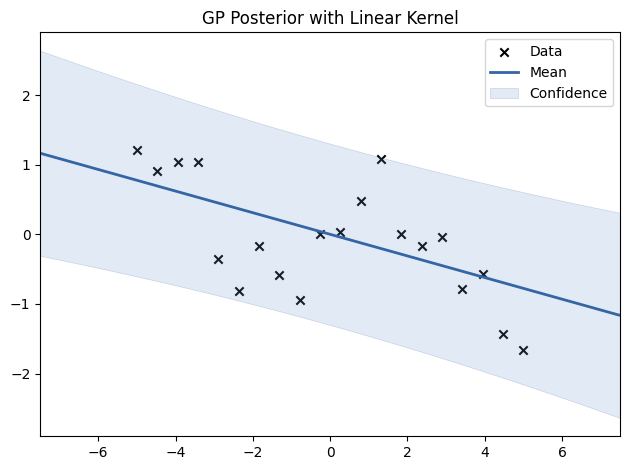

In [61]:
# Define and fit models with different kernels
kernels = {
    "RBF": GPy.kern.RBF(input_dim=1),
    "Matern52": GPy.kern.Matern52(input_dim=1),
    #"Periodic": GPy.kern.Periodic(input_dim=1),
    "Linear": GPy.kern.Linear(input_dim=1),
}

for name, kernel in kernels.items():
    model = GPy.models.GPRegression(X_train, Y_train, kernel)
    model.optimize()
    model.plot(title=f"GP Posterior with {name} Kernel")
    plt.show()


### 6. Training: Hyperparameter Optimization

The kernel hyperparameters (e.g., $\ell$, $\sigma_f^2$, $\sigma_n^2$) are learned by maximizing the **log marginal likelihood**:

$$
\log p(y | X, \theta) = -\frac{1}{2} y^\top [K(X, X) + \sigma_n^2 I]^{-1} y - \frac{1}{2} \log |K(X, X) + \sigma_n^2 I| - \frac{N}{2} \log 2\pi
$$

Where $\theta$ represents the hyperparameters of the kernel.

This mathematical background provides a foundation for understanding the theoretical aspects of Gaussian Process Regression.



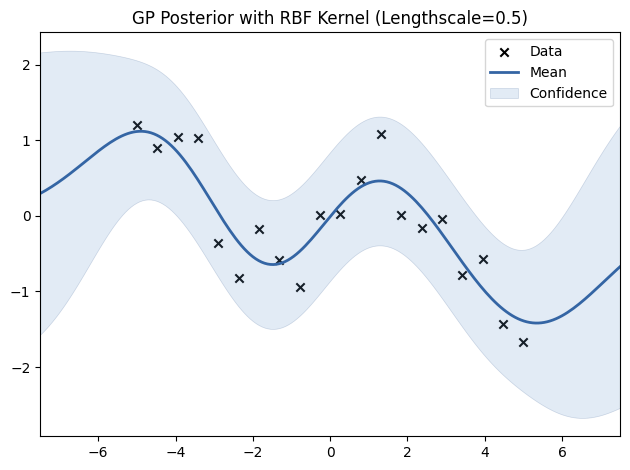

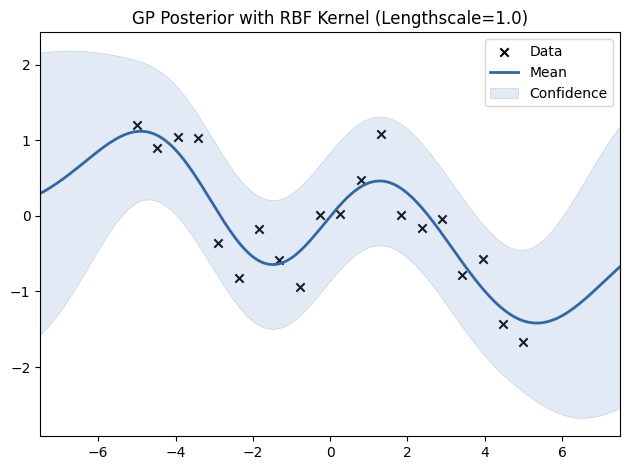

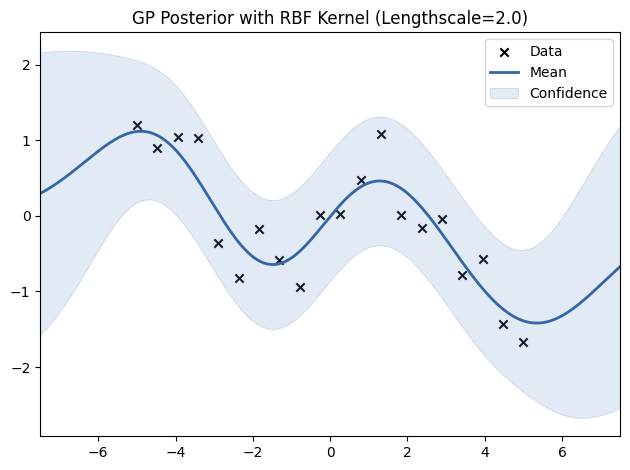

In [62]:
# Experiment with different lengthscales for the RBF kernel
for lengthscale in [0.5, 1.0, 2.0]:
    kernel = GPy.kern.RBF(input_dim=1, lengthscale=lengthscale)
    model = GPy.models.GPRegression(X_train, Y_train, kernel)
    model.optimize()
    model.plot(title=f"GP Posterior with RBF Kernel (Lengthscale={lengthscale})")
    plt.show()

### 7. Experimenting with Different Kernels

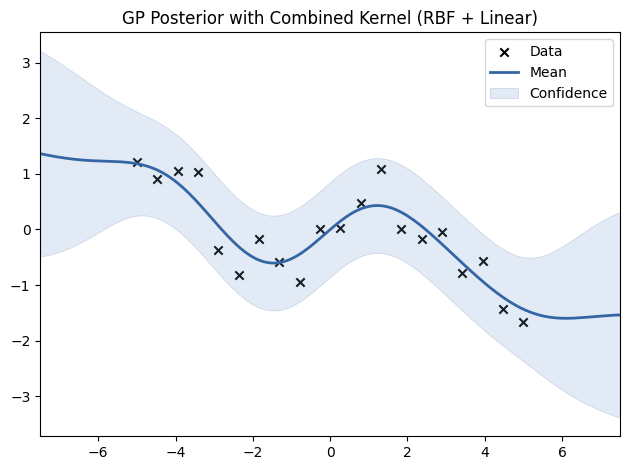

In [63]:
# Experimenting with Combined Kernels
kernel_combined = GPy.kern.RBF(input_dim=1) + GPy.kern.Linear(input_dim=1)
model_combined = GPy.models.GPRegression(X_train, Y_train, kernel_combined)
model_combined.optimize()
model_combined.plot(title="GP Posterior with Combined Kernel (RBF + Linear)")
plt.show()


You can implement a K-fold cross-validation to evaluate model performance more robustly (Note that this code needs changing if you work with time-series data):

In [64]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# K-Fold Cross-Validation
kf = KFold(n_splits=5)
mse_scores = []

for train_index, test_index in kf.split(X_train):
    X_cv_train, X_cv_test = X_train[train_index], X_train[test_index]
    Y_cv_train, Y_cv_test = Y_train[train_index], Y_train[test_index]
    
    # Fit GP model
    model_cv = GPy.models.GPRegression(X_cv_train, Y_cv_train, kernel)
    model_cv.optimize()
    
    # Predict and calculate MSE
    Y_cv_pred, _ = model_cv.predict(X_cv_test)
    mse = mean_squared_error(Y_cv_test, Y_cv_pred)
    mse_scores.append(mse)

print(f"Cross-validated MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")


Cross-validated MSE: 0.7188 ± 0.5631
